# Laboratorio 2 - Aprendizaje de Máquina

## Miembros del grupo

| Nombre             | Código    | Correo electrónico           |
|--------------------|-----------|------------------------------|
| Adrian Velasquez   | 202222737 | a.velasquezs@uniandes.edu.co |

In [376]:
# Importar paquetes
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer, StandardScaler, MinMaxScaler, OneHotEncoder, RobustScaler, Normalizer, MaxAbsScaler
from sklearn.utils import resample

# Preparación

La preparación de los datos se hace con base en la limpieza realizada para el laboratorio 1.
> **Nota**: Se hicieron algunas modificaciones menores a la limpieza que no fueron entregadas en el Laboratorio 1, principalmente algunos ajustes a la eliminación de outliers para evitar valores extremos que podrían afectar el entrenamiento de los modelos polinomiales. Sin embargo, la estructura general del dataset se mantiene igual a la entregada en el Laboratorio 1.

In [377]:
# Variables importantes
DATA_DIRNAME = './data/'
CLEAN_DATA = DATA_DIRNAME + 'clean_data.csv'
TEST_DATA = DATA_DIRNAME + 'test.csv'
MODELS_DIRNAME = './models/'
MODEL_FILENAME = MODELS_DIRNAME + 'model.pkl'

In [378]:
# Importar datos limpios del lab pasado
df = pd.read_csv( CLEAN_DATA )
df.head()

,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,2020-03-21,F,52.000000,109.700000,1.780,34.623154,104.400,103/99,197.000000,0.915,...,High,N,178.000,0.586517,103,99,Hypertension Stage 2,113.190076,18.010,HIGH
1,2020-03-03,F,46.769697,104.469000,1.995,26.248328,86.894,164/90,198.971213,82.000,...,Low,Y,199.458,0.435559,164,90,Hypertension Stage 2,147.000000,18.458,HIGH
2,2022-03-08,M,58.000000,85.880566,1.870,24.559057,99.600,113/91,106.000000,6.809,...,Low,N,187.000,0.532620,113,91,Hypertension Stage 2,33.000000,16.530,HIGH
3,2025-09-17,F,52.000000,107.800000,1.780,34.023482,103.500,111/69,179.000000,73.000,...,Low,Y,178.000,0.581461,111,69,Normal,76.000000,15.930,HIGH
4,2023-08-13,F,50.000000,99.400000,1.670,35.641292,96.300,144/81,256.000000,30.000,...,Moderate,N,167.000,0.576647,144,81,Hypertension Stage 1,196.000000,19.440,HIGH


In [379]:
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (1166, 23)


In [380]:
# Cambiar a tipo fecha
df['Date of Service'] = pd.to_datetime(df['Date of Service'])
df.sample(5)

,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
974,2020-07-10,M,43.000000,57.829000,1.526,24.833425,90.872000,177/72,163.000000,59.000000,...,High,Y,152.624,0.595491,177,72,Hypertension Stage 2,74.0,17.911,LOW
31,2024-01-25,M,45.000000,58.700000,1.730,19.613084,91.557663,136/80,286.000000,73.000000,...,High,Y,173.000,0.529235,136,80,Hypertension Stage 1,183.0,18.440,INTERMEDIARY
152,2021-09-12,M,35.000000,107.800000,1.820,32.544379,87.800000,97/71,198.971213,56.164136,...,High,N,182.000,0.482418,97,71,Normal,39.0,15.870,INTERMEDIARY
650,2025-10-27,M,31.000000,61.213000,1.829,18.298532,84.102000,108/61,145.000000,70.000000,...,High,N,182.902,0.459825,108,61,Normal,45.0,12.229,INTERMEDIARY
911,2021-04-17,F,46.769697,85.880566,1.810,26.214269,75.700000,94/61,144.000000,69.000000,...,Moderate,Y,181.000,0.418232,94,61,Normal,45.0,16.000,INTERMEDIARY


In [381]:
# Separar variables independientes y dependientes
TARGET = 'CVD Risk Score'
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [382]:
# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [383]:
# Verificar dimensiones de los conjuntos de entrenamiento
print(f"Valores de entrenamiento X: {X_train.shape}")
print(f"Valores de entrenamiento y: {y_train.shape[0]}")

Valores de entrenamiento X: (932, 22)
Valores de entrenamiento y: 932


In [384]:
# Verificar dimensiones de los conjuntos de prueba
print(f"Valores de test X: {X_test.shape}")
print(f"Valores de test y: {y_test.shape[0]}")

Valores de test X: (234, 22)
Valores de test y: 234


In [385]:
# Identificar columnas categóricas y numéricas
cat_cols = X_train.select_dtypes(include=['str']).columns
num_cols = X_train.select_dtypes(include=['int64', 'float64', 'datetime']).columns
print(f"Columnas categóricas: {cat_cols}")
print(f"Columnas numéricas: {num_cols}")

Columnas categóricas: Index(['Sex', 'Blood Pressure (mmHg)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD',
       'Blood Pressure Category', 'CVD Risk Level'],
      dtype='str')
Columnas numéricas: Index(['Date of Service', 'Age', 'Weight (kg)', 'Height (m)', 'BMI',
       'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)',
       'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)',
       'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Estimated LDL (mg/dL)'],
      dtype='str')


# Modelo polinomial

Para el modelo polinomial se tendrá en cuenta el `PolynomialFeatures` de `sklearn.preprocessing` para generar características polinomiales a partir de las variables numéricas. Esto permitirá capturar relaciones no lineales entre las variables independientes y la variable dependiente. Se evaluará el rendimiento del modelo polinomial utilizando métricas como el error cuadrático medio (MSE) y el coeficiente de determinación ($R^2$) para comparar con otros modelos lineales y polinomiales regularizados.

## Definir pipeline para modelo polinomial

In [386]:
# Escoger columnas a eliminar de acuerdo al negocio
cols_to_drop = [
    'CVD Risk Level', # Representa una categorización del riesgo, pero el modelo se enfocará en predecir el puntaje de riesgo continuo
    'Date of Service', # No es relevante para el modelo
    'Blood Pressure (mmHg)', # Se puede descomponer en sistólica y diastólica
    'Systolic BP', # Está incluido en Total Cholesterol, por lo que se puede eliminar para evitar multicolinealidad
    'Diastolic BP', # Está incluido en Total Cholesterol, por lo que se puede eliminar para evitar multicolinealidad
    'Weight (kg)', # Se puede descomponer en BMI, por lo que se puede eliminar para evitar multicolinealidad
    'Height (cm)', # Se puede descomponer en BMI, por lo que se puede eliminar para evitar multicolinealidad
    'Height (m)', # Se elimina para evitar multicolinealidad con Height (cm) y Weight (kg)
    'Estimated LDL (mg/dL)', # Se puede descomponer en Total Cholesterol, por lo que se puede eliminar para evitar multicolinealidad
    'HDL (mg/dL)', # Se puede descomponer en Total Cholesterol, por lo que se puede eliminar para evitar multicolinealidad
    'Blood Pressure Category', # Representa una categorización de la presión arterial, pero el modelo se enfocará en predecir el puntaje de riesgo continuo
    'Abdominal Circumference (cm)', # Se decompone en Waist-to-Height Ratio, por lo que se puede eliminar para evitar multicolinealidad
]

In [387]:
# Definir función para eliminar columnas
def drop_columns( xt ):
    return xt.drop(columns=cols_to_drop)

dropper = FunctionTransformer(drop_columns)

In [388]:
# Pipeline para transformar variables numéricas con polinomios
poli_num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ('poly', PolynomialFeatures(degree=2))
    ]
)

In [389]:
# Pipeline para transformar variables categóricas con one-hot encoding y polinomios
poli_cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [390]:
# Adquirir nuevamente las columnas cat y num
cat_cols = [c for c in cat_cols if c not in cols_to_drop]
num_cols = [c for c in num_cols if c not in cols_to_drop]

In [391]:
# Combinar transformadores numéricos y categóricos en un preprocesador
poli_preprocessor = ColumnTransformer(
    transformers=[
        ("num", poli_num_transformer, num_cols), # Aplicar el transformador polinomial a las columnas numéricas
        ("cat", poli_cat_transformer, cat_cols) # Aplicar el transformador de one-hot encoding a las columnas categóricas
    ]
)

In [392]:
# Combinar transformadores en un preprocesador
poli_pipe = Pipeline(
    steps=[
        ("dropper", dropper), # Aplicar el transformador de eliminación a todas las columnas
        ("preprocessor", poli_preprocessor), # Aplicar el preprocesador polinomial a las columnas restantes
        ("scaler", StandardScaler()), # Escalado de características post preprocesamiento
        ("model", LinearRegression()), # Modelo de regresión
    ]
)

In [393]:
# Visualizar pipeline
set_config(display="diagram")
poli_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('dropper', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...t 0x113b47ab0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments t

## Modelo polinomial de grado 2

In [394]:
# Hacer fit del modelo
poli_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('dropper', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...t 0x113b47ab0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments t

In [395]:
# Ver los coeficientes del modelo
poli_model = poli_pipe.named_steps["model"]
num_coeficientes = len(poli_model.coef_)
print("Número de coeficientes:", num_coeficientes)

Número de coeficientes: 32


### Validación del modelo polinomial

In [396]:
# Rendimiento inicial
y_train_pred_poli = poli_pipe.predict(X_train)

In [397]:
# Métricas
print(f'------ Modelo de regresión polinomial grado 2 ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_poli)):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_poli):.4f}")
print(f'R^2: {r2_score(y_train, y_train_pred_poli):.4f}')

------ Modelo de regresión polinomial grado 2 ----
RMSE: 1.5000
MAE: 1.1359
R^2: 0.6023


### Estimación de generalización del modelo polinomial con validación cruzada

In [398]:
# Predecir
y_test_pred_poli = poli_pipe.predict(X_test)

In [399]:
# Métricas
print(f'------ Modelo de regresión polinomial grado 2 - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_poli)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_poli):.4f}")
print(f'R^2: {r2_score(y_test, y_test_pred_poli):.4f}')

------ Modelo de regresión polinomial grado 2 - Resultados en test ----
RMSE: 1.4591
MAE: 1.1070
R^2: 0.6282


## Búsqueda de hiperparámetros para modelo polinomial

In [400]:
# Definir el grid para GridSearchCV incluyendo grado polinomial y estrategia de escalamiento
# Se exploran grados del 1 al 7 y dos estrategias de escalamiento dentro del pipeline

scalers = [StandardScaler(), MinMaxScaler(), MaxAbsScaler(), RobustScaler(), Normalizer()]

param_grid_poly = {
    'preprocessor__num__poly__degree': [1, 2, 3, 4, 5, 6, 7],
    'preprocessor__num__scaler': scalers,
}

In [401]:
# Definir el GridSearchCV
# Se usa neg_root_mean_squared_error como métrica (queremos minimizar RMSE)
grid_poly = GridSearchCV(
    estimator=poli_pipe,
    param_grid=param_grid_poly,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)

In [402]:
# Ajustar el GridSearchCV con los datos de entrenamiento
grid_poly.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocessor__num__poly__degree': [1, 2, ...], 'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [403]:
# Mejores hiperparámetros encontrados
print("Mejor configuración:", grid_poly.best_params_)
print(f"Mejor RMSE CV: {-grid_poly.best_score_:.4f}")

Mejor configuración: {'preprocessor__num__poly__degree': 2, 'preprocessor__num__scaler': MinMaxScaler()}
Mejor RMSE CV: 1.5552


In [404]:
mejor_modelo_poly = grid_poly.best_estimator_

In [405]:
# Evaluación del mejor modelo polinomial en el conjunto de prueba
y_test_pred_poly_best = mejor_modelo_poly.predict(X_test)
print('------ Mejor modelo polinomial (GridSearchCV) - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_poly_best)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_poly_best):.4f}")
print(f"R^2: {r2_score(y_test, y_test_pred_poly_best):.4f}")

------ Mejor modelo polinomial (GridSearchCV) - Resultados en test ----
RMSE: 1.4591
MAE: 1.1070
R^2: 0.6282


In [406]:
# Validación cruzada del mejor modelo polinomial para estimar estabilidad
cv_rmse_poly = -cross_val_score(mejor_modelo_poly, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(f"RMSE promedio CV: {cv_rmse_poly.mean():.4f}")
print(f"Desviación estándar: {cv_rmse_poly.std():.4f}")
print(f"Intervalo (±2 desv): [{cv_rmse_poly.mean() - 2*cv_rmse_poly.std():.4f}, {cv_rmse_poly.mean() + 2*cv_rmse_poly.std():.4f}]")

RMSE promedio CV: 1.5552
Desviación estándar: 0.1141
Intervalo (±2 desv): [1.3269, 1.7835]


## Curvas de validación para modelo polinomial

In [407]:
# Curvas de validación para el modelo polinomial
# Se evalúan grados del 1 al 7 con validación cruzada de 5 folds.
# Para cada grado se registra el RMSE medio y la desviación estándar
# tanto en entrenamiento como en validación.

degrees = [1, 2, 3, 4, 5, 6, 7]
cv = KFold(n_splits=5, shuffle=True, random_state=42)

train_rmse_mean, train_rmse_std = [], []
val_rmse_mean,   val_rmse_std   = [], []

for degree in degrees:
    pipe_d = copy.deepcopy(poli_pipe)
    pipe_d.set_params(preprocessor__num__poly__degree=degree)

    train_scores, val_scores = [], []

    for train_idx, val_idx in cv.split(X_train):
        X_tr,  X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr,  y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipe_d.fit(X_tr, y_tr)
        train_scores.append(np.sqrt(mean_squared_error(y_tr,  pipe_d.predict(X_tr))))
        val_scores.append(np.sqrt(mean_squared_error(y_val, pipe_d.predict(X_val))))

    train_rmse_mean.append(np.mean(train_scores))
    train_rmse_std.append(np.std(train_scores))
    val_rmse_mean.append(np.mean(val_scores))
    val_rmse_std.append(np.std(val_scores))

train_rmse_mean = np.array(train_rmse_mean)
train_rmse_std = np.array(train_rmse_std)
val_rmse_mean = np.array(val_rmse_mean)
val_rmse_std = np.array(val_rmse_std)
best_degree = degrees[int(np.argmin(val_rmse_mean))]
print(f"Grado con menor RMSE de validación: {best_degree}")

Grado con menor RMSE de validación: 2


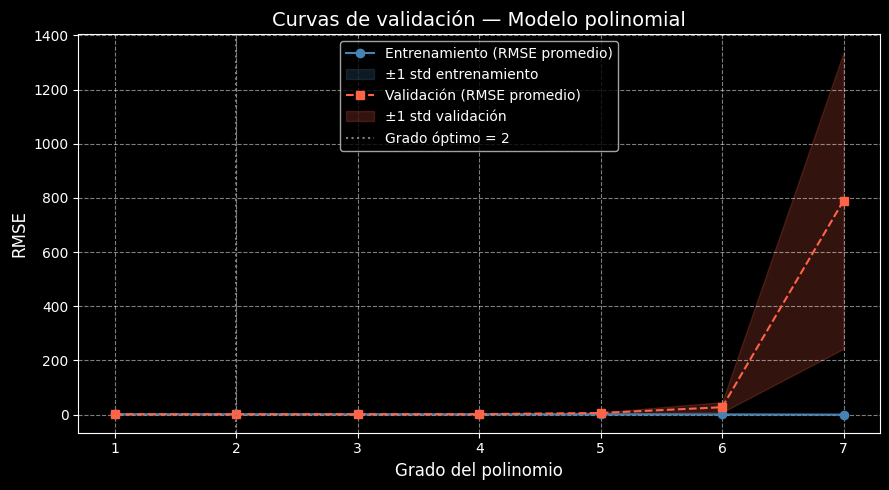

In [408]:
# Gráfica de curvas de validación
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(degrees, train_rmse_mean, 'o-', color='steelblue', label='Entrenamiento (RMSE promedio)')
ax.fill_between(degrees,
                train_rmse_mean - train_rmse_std,
                train_rmse_mean + train_rmse_std,
                alpha=0.20, color='steelblue', label='±1 std entrenamiento')

ax.plot(degrees, val_rmse_mean, 's--', color='tomato', label='Validación (RMSE promedio)')
ax.fill_between(degrees,
                val_rmse_mean - val_rmse_std,
                val_rmse_mean + val_rmse_std,
                alpha=0.20, color='tomato', label='±1 std validación')

ax.axvline(x=best_degree, color='gray', linestyle=':', linewidth=1.5,
           label=f'Grado óptimo = {best_degree}')

ax.set_xlabel('Grado del polinomio', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Curvas de validación — Modelo polinomial', fontsize=14)
ax.set_xticks(degrees)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [409]:
# Tabla de resumen de las curvas de validación
resultados_cv_poly = pd.DataFrame({
    'Grado': degrees,
    'RMSE Train (media)': np.round(train_rmse_mean, 4),
    'RMSE Train (std)': np.round(train_rmse_std, 4),
    'RMSE Val (media)': np.round(val_rmse_mean, 4),
    'RMSE Val (std)': np.round(val_rmse_std, 4),
})
print(resultados_cv_poly.to_string(index=False))
print(f"\nGrado con menor RMSE de validación: {best_degree}")

 Grado  RMSE Train (media)  RMSE Train (std)  RMSE Val (media)  RMSE Val (std)
     1              1.5502            0.0302            1.5769          0.1159
     2              1.4928            0.0303            1.5604          0.1203
     3              1.4065            0.0316            1.5971          0.1511
     4              1.2885            0.0228            1.8490          0.1878
     5              1.0926            0.0330            5.9748          2.4302
     6              0.7856            0.0270           27.2605         19.0547
     7              0.0000            0.0000          790.1757        547.0570

Grado con menor RMSE de validación: 2


### Interpretación de las curvas de validación

Los resultados de la tabla confirman el trade-off sesgo-varianza. El sobreajuste comienza a partir del grado 4, donde el RMSE de validación sube drásticamente respecto a los anteriores, mientras el de entrenamiento sigue bajando. La desviación estándar de
la validación también aumenta bastante, lo que indica alta inestabilidad. El grado óptimo sin regularización es 2, que coincide con el resultado de GridSearchCV.

# Modelos de regresión lineal regularizados

## Construcción de pipelines para Ridge y Lasso

Se construyen pipelines independientes para Ridge (regularización L2) y Lasso (regularización L1), 
incluyendo las mismas etapas de preprocesamiento del modelo polinomial base (grado=1).
La búsqueda de hiperparámetros explora el parámetro de penalización `alpha` y la estrategia de 
escalamiento, todo dentro del pipeline para evitar data leakage.

In [410]:
# Pipeline para Ridge con grado polinomial = 1 (lineal)
ridge_num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ('poly', PolynomialFeatures(degree=1, include_bias=False))
])

ridge_preprocessor = ColumnTransformer(transformers=[
    ("num", ridge_num_transformer, num_cols),
    ("cat", poli_cat_transformer,  cat_cols)
])

ridge_pipe = Pipeline(steps=[
    ("dropper", dropper),
    ("preprocessor", ridge_preprocessor),
    ("model", Ridge())
])

# Pipeline para Lasso con grado polinomial = 1 (lineal)
lasso_num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ('poly', PolynomialFeatures(degree=1, include_bias=False))
])

lasso_preprocessor = ColumnTransformer(transformers=[
    ("num", lasso_num_transformer, num_cols),
    ("cat", poli_cat_transformer,  cat_cols)
])

lasso_pipe = Pipeline(steps=[
    ("dropper", dropper),
    ("preprocessor", lasso_preprocessor),
    ("model", Lasso(max_iter=10000))
])

In [411]:
# Grid de hiperparámetros para Ridge: alpha y estrategia de escalamiento
param_grid_ridge = {
    'preprocessor__num__scaler': scalers,
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
}

grid_ridge = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)
grid_ridge.fit(X_train, y_train)

print("Mejor configuración Ridge:", grid_ridge.best_params_)
print(f"Mejor RMSE CV: {-grid_ridge.best_score_:.4f}")

Mejor configuración Ridge: {'model__alpha': 10.0, 'preprocessor__num__scaler': StandardScaler()}
Mejor RMSE CV: 1.5711


In [412]:
# Grid de hiperparámetros para Lasso: alpha y estrategia de escalamiento
param_grid_lasso = {
    'preprocessor__num__scaler': scalers,
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
}

grid_lasso = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=param_grid_lasso,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)
grid_lasso.fit(X_train, y_train)

print("Mejor configuración Lasso:", grid_lasso.best_params_)
print(f"Mejor RMSE CV: {-grid_lasso.best_score_:.4f}")

Mejor configuración Lasso: {'model__alpha': 0.01, 'preprocessor__num__scaler': RobustScaler()}
Mejor RMSE CV: 1.5691


In [413]:
# Evaluar mejores modelos en el conjunto de prueba
best_ridge = grid_ridge.best_estimator_
best_lasso = grid_lasso.best_estimator_

y_pred_ridge = best_ridge.predict(X_test)
y_pred_lasso = best_lasso.predict(X_test)

print('------ Mejor modelo Ridge - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_ridge):.4f}")
print(f"R^2: {r2_score(y_test, y_pred_ridge):.4f}")

print()
print('------ Mejor modelo Lasso - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lasso):.4f}")
print(f"R^2: {r2_score(y_test, y_pred_lasso):.4f}")

------ Mejor modelo Ridge - Resultados en test ----
RMSE: 1.4821
MAE: 1.1357
R^2: 0.6164

------ Mejor modelo Lasso - Resultados en test ----
RMSE: 1.4752
MAE: 1.1328
R^2: 0.6199


In [414]:
# Validación cruzada de los mejores modelos para estimar estabilidad
cv_rmse_ridge = -cross_val_score(best_ridge, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_rmse_lasso = -cross_val_score(best_lasso, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

print(f"Ridge - RMSE promedio CV: {cv_rmse_ridge.mean():.4f} (+/-{cv_rmse_ridge.std():.4f})")
print(f"Lasso - RMSE promedio CV: {cv_rmse_lasso.mean():.4f} (+/-{cv_rmse_lasso.std():.4f})")

Ridge - RMSE promedio CV: 1.5711 (+/-0.0837)
Lasso - RMSE promedio CV: 1.5691 (+/-0.0841)


## Análisis de coeficientes: Ridge vs Lasso vs Lineal

In [415]:
# Comparación de la magnitud de coeficientes entre Ridge, Lasso y modelo lineal base
# Primero construimos un modelo lineal de referencia sin regularización
linear_num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler",  StandardScaler()),
    ('poly',    PolynomialFeatures(degree=1, include_bias=False))
])
linear_preprocessor = ColumnTransformer(transformers=[
    ("num", linear_num_transformer, num_cols),
    ("cat", poli_cat_transformer,  cat_cols)
])
linear_pipe_base = Pipeline(steps=[
    ("dropper",      dropper),
    ("preprocessor", linear_preprocessor),
    ("model",        LinearRegression())
])
linear_pipe_base.fit(X_train, y_train)
y_pred_linear = linear_pipe_base.predict(X_test)
cv_rmse_linear = -cross_val_score(linear_pipe_base, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

print('------ Modelo Lineal sin regularización - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_linear)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_linear):.4f}")
print(f"R^2:   {r2_score(y_test, y_pred_linear):.4f}")
print(f"RMSE CV: {cv_rmse_linear.mean():.4f} (±{cv_rmse_linear.std():.4f})")

------ Modelo Lineal sin regularización - Resultados en test ----
RMSE: 1.4793
MAE:  1.1333
R^2:   0.6178
RMSE CV: 1.5712 (±0.0835)


In [416]:
# Obtener nombres de características y coeficientes de cada modelo
def get_feature_names_coefs(pipe):
    preprocessor = pipe.named_steps['preprocessor']
    poly_transformer = preprocessor.named_transformers_['num'].named_steps['poly']
    num_feature_names = poly_transformer.get_feature_names_out(num_cols)
    
    # Nombres de características OHE
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    try:
        cat_feature_names = ohe.get_feature_names_out(cat_cols)
    except:
        cat_feature_names = []
    
    all_names = list(num_feature_names) + list(cat_feature_names)
    coefs = pipe.named_steps['model'].coef_
    return all_names, coefs

names_linear, coefs_linear = get_feature_names_coefs(linear_pipe_base)
names_ridge, coefs_ridge  = get_feature_names_coefs(best_ridge)
names_lasso, coefs_lasso  = get_feature_names_coefs(best_lasso)

# DataFrame comparativo
coef_df = pd.DataFrame({
    'Feature': names_linear,
    'Lineal': coefs_linear,
    'Ridge': coefs_ridge,
    'Lasso': coefs_lasso,
})
coef_df['|Lineal|'] = coef_df['Lineal'].abs()
coef_df = coef_df.sort_values('|Lineal|', ascending=False)
print(coef_df[['Feature', 'Lineal', 'Ridge', 'Lasso']].to_string(index=False))

                         Feature    Lineal     Ridge         Lasso
       Total Cholesterol (mg/dL)  1.106044  1.094370  1.777957e+00
               Diabetes Status_Y  0.958082  0.938560  5.237608e-15
               Diabetes Status_N -0.958082 -0.938560 -1.880025e+00
                             BMI  0.941905  0.932802  1.485852e+00
     Fasting Blood Sugar (mg/dL)  0.149129  0.148186  1.998666e-01
                             Age  0.145662  0.143973  1.884987e-01
         Family History of CVD_N -0.077678 -0.076273 -1.121039e-01
         Family History of CVD_Y  0.077678  0.076273  1.067359e-16
     Physical Activity Level_Low  0.051696  0.050184  3.129594e-02
    Physical Activity Level_High -0.039064 -0.036906 -0.000000e+00
                           Sex_F -0.035234 -0.034181 -2.718674e-02
                           Sex_M  0.035234  0.034181  3.049666e-17
                Smoking Status_N  0.024213  0.024125  1.124756e-02
                Smoking Status_Y -0.024213 -0.024125 -0.000000

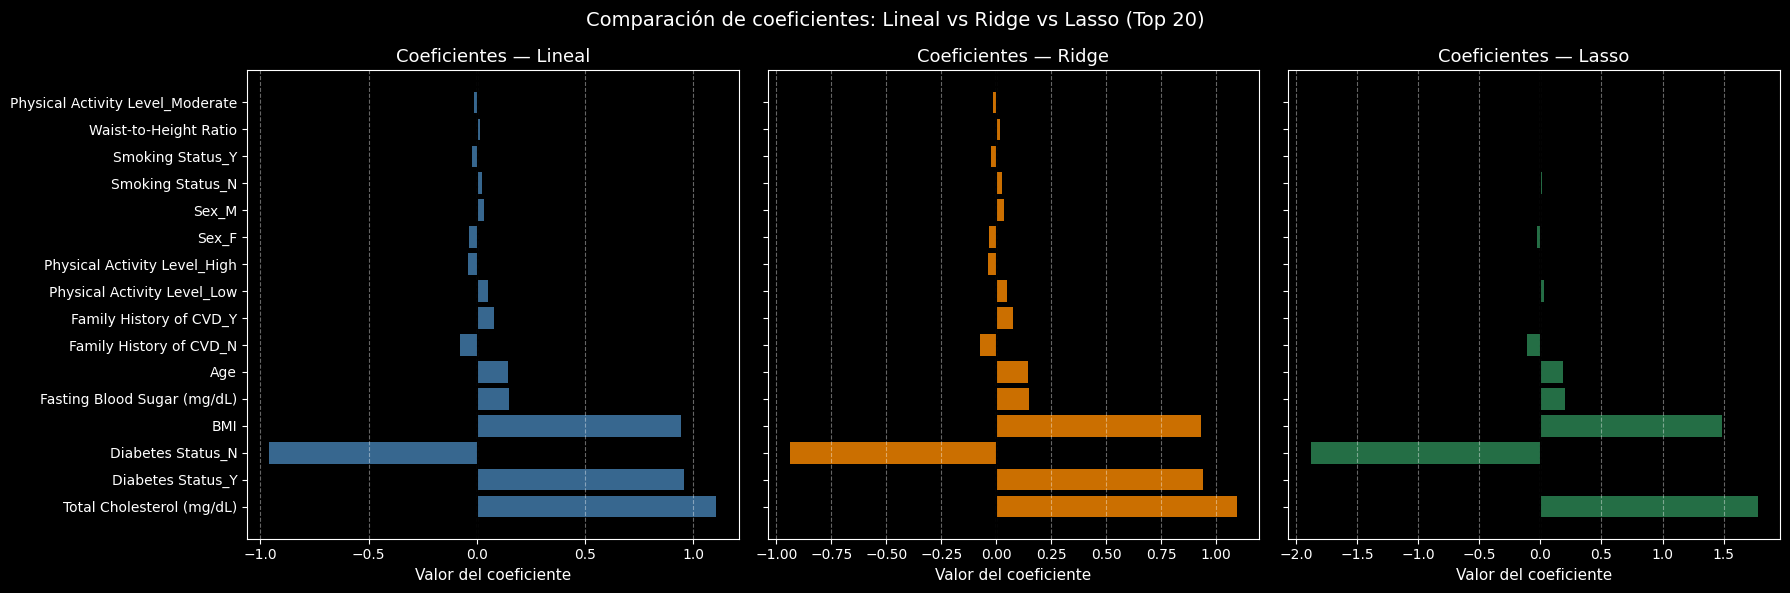

In [417]:
# Visualización de coeficientes — Top 20 por magnitud absoluta (lineal)
top20 = coef_df.head(20)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
colors = ['steelblue', 'darkorange', 'seagreen']
models = ['Lineal', 'Ridge', 'Lasso']

for ax, model, color in zip(axes, models, colors):
    ax.barh(top20['Feature'], top20[model], color=color, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Coeficientes — {model}', fontsize=13)
    ax.set_xlabel('Valor del coeficiente', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')

plt.suptitle('Comparación de coeficientes: Lineal vs Ridge vs Lasso (Top 20)', fontsize=14)
plt.tight_layout()
plt.show()

In [418]:
# Variables llevadas a cero por Lasso (selección automática de características)
lasso_zero = coef_df[coef_df['Lasso'] == 0.0]['Feature'].tolist()
lasso_nonzero = coef_df[coef_df['Lasso'] != 0.0]

print(f"Número de variables llevadas a 0 por Lasso: {len(lasso_zero)} de {len(coef_df)}")
print(f"Variables eliminadas:\n{lasso_zero}")
print(f"\nVariables seleccionadas por Lasso ({len(lasso_nonzero)}):")
print(lasso_nonzero[['Feature', 'Lasso']].sort_values('Lasso', key=abs, ascending=False).to_string(index=False))

Número de variables llevadas a 0 por Lasso: 3 de 16
Variables eliminadas:
['Physical Activity Level_High', 'Smoking Status_Y', 'Physical Activity Level_Moderate']

Variables seleccionadas por Lasso (13):
                    Feature         Lasso
          Diabetes Status_N -1.880025e+00
  Total Cholesterol (mg/dL)  1.777957e+00
                        BMI  1.485852e+00
Fasting Blood Sugar (mg/dL)  1.998666e-01
                        Age  1.884987e-01
    Family History of CVD_N -1.121039e-01
Physical Activity Level_Low  3.129594e-02
                      Sex_F -2.718674e-02
           Smoking Status_N  1.124756e-02
      Waist-to-Height Ratio  4.421107e-03
          Diabetes Status_Y  5.237608e-15
    Family History of CVD_Y  1.067359e-16
                      Sex_M  3.049666e-17


### Interpretación de la regularización

La regularización ayudó a mejorar los resultados de las métricas, en particular en Lasso. Por otro lado, las variables llevadas a 0 por Lasso fueron `Physical Activity Level_High`, `Smoking Status_Y` y `Physical Activity Level_Moderate`. Esto sugiere que en el contexto de Alpes Health, estas variables podrían no ser tan relevantes para predecir el puntaje de riesgo cardiovascular, o que su efecto está siendo capturado por otras variables correlacionadas.


# Modelo de regresión polinomial regularizado

## Construcción del pipeline

Se combina `PolynomialFeatures` con regularización Ridge y Lasso. La búsqueda de hiperparámetros 
explora simultáneamente el **grado del polinomio**, el **parámetro de penalización** y la 
**estrategia de escalamiento**, lo que permite evaluar si la regularización controla el sobreajuste 
al aumentar la complejidad.

In [419]:
# Pipeline polinomial regularizado con Ridge
poly_ridge_num = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False))
])
poly_ridge_preprocessor = ColumnTransformer(transformers=[
    ("num", poly_ridge_num, num_cols),
    ("cat", poli_cat_transformer, cat_cols)
])
poly_ridge_pipe = Pipeline(steps=[
    ("dropper", dropper),
    ("preprocessor", poly_ridge_preprocessor),
    ("model", Ridge())
])

# Pipeline polinomial regularizado con Lasso
poly_lasso_num = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False))
])
poly_lasso_preprocessor = ColumnTransformer(transformers=[
    ("num", poly_lasso_num, num_cols),
    ("cat", poli_cat_transformer, cat_cols)
])
poly_lasso_pipe = Pipeline(steps=[
    ("dropper", dropper),
    ("preprocessor", poly_lasso_preprocessor),
    ("model", Lasso(max_iter=70000))
])

In [420]:
# Grid de hiperparámetros para polinomial + Ridge
# Explorar grado, alpha y escalamiento
param_grid_poly_ridge = {
    'preprocessor__num__poly__degree': [1, 2, 3, 4],
    'preprocessor__num__scaler': scalers,
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
}

grid_poly_ridge = GridSearchCV(
    estimator=poly_ridge_pipe,
    param_grid=param_grid_poly_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)
grid_poly_ridge.fit(X_train, y_train)

print("Mejor configuración Polinomial+Ridge:", grid_poly_ridge.best_params_)
print(f"Mejor RMSE CV: {-grid_poly_ridge.best_score_:.4f}")

Mejor configuración Polinomial+Ridge: {'model__alpha': 1.0, 'preprocessor__num__poly__degree': 4, 'preprocessor__num__scaler': MinMaxScaler()}
Mejor RMSE CV: 1.5416


In [421]:
# Grid de hiperparámetros para polinomial + Lasso
param_grid_poly_lasso = {
    'preprocessor__num__poly__degree': [1, 2, 3, 4],
    'preprocessor__num__scaler': scalers,
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
}

grid_poly_lasso = GridSearchCV(
    estimator=poly_lasso_pipe,
    param_grid=param_grid_poly_lasso,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)
grid_poly_lasso.fit(X_train, y_train)

print("Mejor configuración Polinomial+Lasso:", grid_poly_lasso.best_params_)
print(f"Mejor RMSE CV: {-grid_poly_lasso.best_score_:.4f}")

Mejor configuración Polinomial+Lasso: {'model__alpha': 0.001, 'preprocessor__num__poly__degree': 4, 'preprocessor__num__scaler': MaxAbsScaler()}
Mejor RMSE CV: 1.5360


In [422]:
# Evaluación de los mejores modelos polinomiales regularizados en test
best_poly_ridge = grid_poly_ridge.best_estimator_
best_poly_lasso = grid_poly_lasso.best_estimator_

y_pred_poly_ridge = best_poly_ridge.predict(X_test)
y_pred_poly_lasso = best_poly_lasso.predict(X_test)

print('------ Polinomial + Ridge - Resultados en test ----')
print(f"Mejor configuración Polinomial+Ridge: {grid_poly_ridge.best_params_}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly_ridge)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_poly_ridge):.4f}")
print(f"R^2:   {r2_score(y_test, y_pred_poly_ridge):.4f}")

print()
print('------ Polinomial + Lasso - Resultados en test ----')
print(f"Mejor configuración Polinomial+Lasso: {grid_poly_lasso.best_params_}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly_lasso)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_poly_lasso):.4f}")
print(f"R^2:   {r2_score(y_test, y_pred_poly_lasso):.4f}")

------ Polinomial + Ridge - Resultados en test ----
Mejor configuración Polinomial+Ridge: {'model__alpha': 1.0, 'preprocessor__num__poly__degree': 4, 'preprocessor__num__scaler': MinMaxScaler()}
RMSE: 1.4444
MAE:  1.0992
R^2:   0.6356

------ Polinomial + Lasso - Resultados en test ----
Mejor configuración Polinomial+Lasso: {'model__alpha': 0.001, 'preprocessor__num__poly__degree': 4, 'preprocessor__num__scaler': MaxAbsScaler()}
RMSE: 1.4521
MAE:  1.1027
R^2:   0.6317


In [423]:
# Validación cruzada de los modelos polinomiales regularizados
cv_rmse_poly_ridge = -cross_val_score(best_poly_ridge, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_rmse_poly_lasso = -cross_val_score(best_poly_lasso, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

print(f"Poly+Ridge - RMSE promedio CV: {cv_rmse_poly_ridge.mean():.4f} (+/-{cv_rmse_poly_ridge.std():.4f})")
print(f"Poly+Lasso - RMSE promedio CV: {cv_rmse_poly_lasso.mean():.4f} (+/-{cv_rmse_poly_lasso.std():.4f})")

Poly+Ridge - RMSE promedio CV: 1.5416 (+/-0.1106)
Poly+Lasso - RMSE promedio CV: 1.5360 (+/-0.1103)


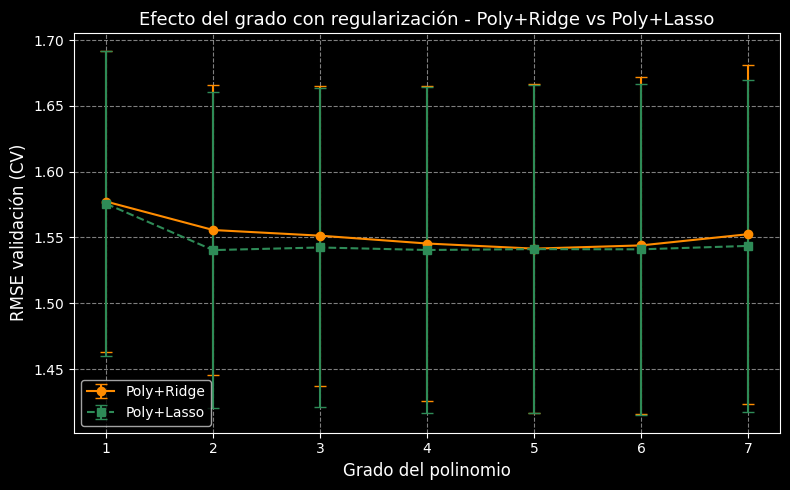

In [424]:
# Curvas de validación para Poly+Ridge y Poly+Lasso: efecto del grado con regularización
degrees_reg = [1, 2, 3, 4, 5, 6, 7]
alphas_fixed = {
    'ridge': grid_poly_ridge.best_params_['model__alpha'],
    'lasso': grid_poly_lasso.best_params_['model__alpha'],
}
scaler_fixed = {
    'ridge': grid_poly_ridge.best_params_['preprocessor__num__scaler'],
    'lasso': grid_poly_lasso.best_params_['preprocessor__num__scaler'],
}

cv_kf = KFold(n_splits=5, shuffle=True, random_state=42)

val_ridge_mean, val_ridge_std = [], []
val_lasso_mean, val_lasso_std = [], []

iter_list = [
        (val_ridge_mean, val_ridge_std, poly_ridge_pipe, 'ridge'),
        (val_lasso_mean, val_lasso_std, poly_lasso_pipe, 'lasso'),
    ]

for degree in degrees_reg:
    for means_list, stds_list, pipe_base, model_key in iter_list:
        p = copy.deepcopy(pipe_base)
        p.set_params(
            preprocessor__num__poly__degree=degree,
            preprocessor__num__scaler=scaler_fixed[model_key],
            model__alpha=alphas_fixed[model_key],
        )
        scores = []
        for tr_idx, val_idx in cv_kf.split(X_train):
            p.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
            scores.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], p.predict(X_train.iloc[val_idx]))))
        means_list.append(np.mean(scores))
        stds_list.append(np.std(scores))

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(degrees_reg, val_ridge_mean, yerr=val_ridge_std, fmt='o-', color='darkorange', capsize=4, label='Poly+Ridge')
ax.errorbar(degrees_reg, val_lasso_mean, yerr=val_lasso_std, fmt='s--', color='seagreen', capsize=4, label='Poly+Lasso')
ax.set_xlabel('Grado del polinomio', fontsize=12)
ax.set_ylabel('RMSE validación (CV)', fontsize=12)
ax.set_title('Efecto del grado con regularización - Poly+Ridge vs Poly+Lasso', fontsize=13)
ax.set_xticks(degrees_reg)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

### Interpretación

Podemos ver que el comportamiento del RMSE de validación es muy similar entre Lasso y Ridge a medida que aumenta el grado del polinomio. Sin embargo, Lasso muestra una ligera ventaja en todos los casos. A pesar de esto, el mejor modelo Ridge supera levemente al mejor Modelo Lasso en todas las métricas. Esto sugiere que, aunque Lasso es más agresivo en la reducción de coeficientes, en este caso específico la regularización L2 de Ridge logra un mejor equilibrio entre sesgo y varianza, controlando el sobreajuste sin eliminar completamente características potencialmente relevantes.
En general, ambos modelos tienen tendencia a mejorar a medida que aumenta el grado, con un aumento a partir del grado 4, lo que indica que la regularización está ayudando a controlar el sobreajuste incluso con polinomios más complejos.

# Comparación y selección del mejor modelo

In [425]:
# Tabla comparativa de todos los modelos evaluados
models_summary = {
    'Modelo': ['Lineal', 'Poly (GridSearch)', 'Ridge', 'Lasso', 'Poly+Ridge', 'Poly+Lasso'],
    'RMSE Test': [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_poly_best)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_poly_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_poly_lasso)),
    ],
    'MAE Test': [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_test_pred_poly_best),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_poly_ridge),
        mean_absolute_error(y_test, y_pred_poly_lasso),
    ],
    'R^2 Test': [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_test_pred_poly_best),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_poly_ridge),
        r2_score(y_test, y_pred_poly_lasso),
    ],
    'RMSE CV (media)': [
        cv_rmse_linear.mean(),
        cv_rmse_poly.mean(),
        cv_rmse_ridge.mean(),
        cv_rmse_lasso.mean(),
        cv_rmse_poly_ridge.mean(),
        cv_rmse_poly_lasso.mean(),
    ],
    'RMSE CV (std)': [
        cv_rmse_linear.std(),
        cv_rmse_poly.std(),
        cv_rmse_ridge.std(),
        cv_rmse_lasso.std(),
        cv_rmse_poly_ridge.std(),
        cv_rmse_poly_lasso.std(),
    ],
    'Parametros': [
        'N/A',
        f"Grado={grid_poly.best_params_['preprocessor__num__poly__degree']}, Escalador={grid_poly.best_params_['preprocessor__num__scaler']}",
        f"Alpha={grid_ridge.best_params_['model__alpha']}, Escalador={grid_ridge.best_params_['preprocessor__num__scaler']}",
        f"Alpha={grid_lasso.best_params_['model__alpha']}, Escalador={grid_lasso.best_params_['preprocessor__num__scaler']}",
        f"Grado={grid_poly_ridge.best_params_['preprocessor__num__poly__degree']}, Alpha={grid_poly_ridge.best_params_['model__alpha']}, Escalador={grid_poly_ridge.best_params_['preprocessor__num__scaler']}",
        f"Grado={grid_poly_lasso.best_params_['preprocessor__num__poly__degree']}, Alpha={grid_poly_lasso.best_params_['model__alpha']}, Escalador={grid_poly_lasso.best_params_['preprocessor__num__scaler']}",
    ]
}

df_summary = pd.DataFrame(models_summary).round(4)
print(df_summary.to_string(index=False))

           Modelo  RMSE Test  MAE Test  R^2 Test  RMSE CV (media)  RMSE CV (std)                                     Parametros
           Lineal     1.4793    1.1333    0.6178           1.5712         0.0835                                            N/A
Poly (GridSearch)     1.4591    1.1070    0.6282           1.5552         0.1141              Grado=2, Escalador=MinMaxScaler()
            Ridge     1.4821    1.1357    0.6164           1.5711         0.0837         Alpha=10.0, Escalador=StandardScaler()
            Lasso     1.4752    1.1328    0.6199           1.5691         0.0841           Alpha=0.01, Escalador=RobustScaler()
       Poly+Ridge     1.4444    1.0992    0.6356           1.5416         0.1106   Grado=4, Alpha=1.0, Escalador=MinMaxScaler()
       Poly+Lasso     1.4521    1.1027    0.6317           1.5360         0.1103 Grado=4, Alpha=0.001, Escalador=MaxAbsScaler()


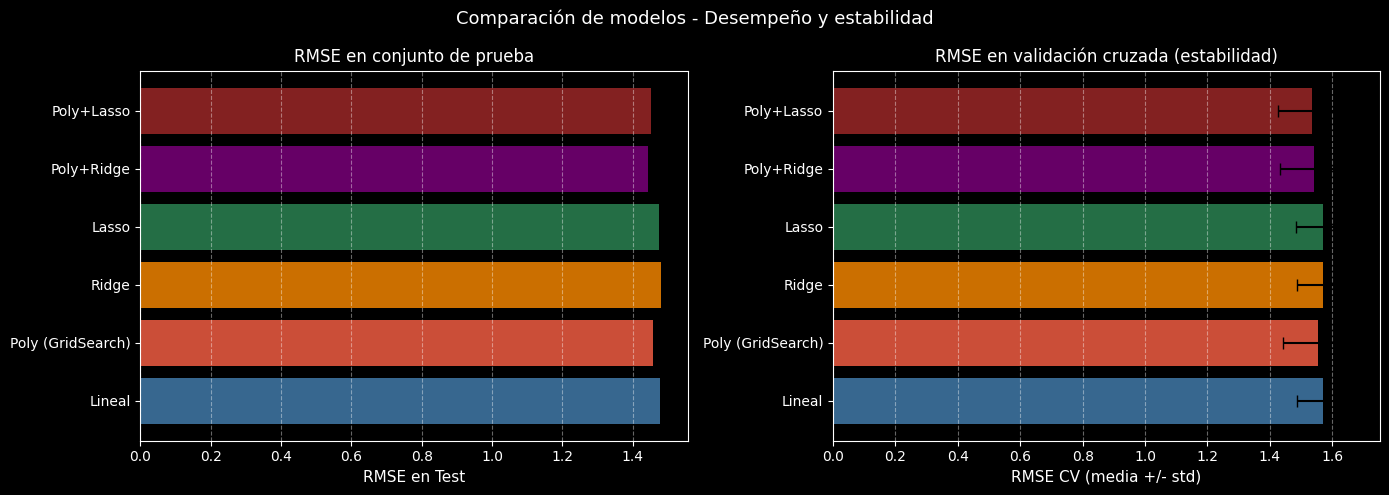

In [426]:
# Visualización comparativa: RMSE test vs RMSE CV (con barras de error)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = df_summary['Modelo']
colors_bar = ['steelblue', 'tomato', 'darkorange', 'seagreen', 'purple', 'brown']

# RMSE Test
axes[0].barh(model_names, df_summary['RMSE Test'], color=colors_bar, alpha=0.8)
axes[0].set_xlabel('RMSE en Test', fontsize=11)
axes[0].set_title('RMSE en conjunto de prueba', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.4, axis='x')

# RMSE CV con std
axes[1].barh(model_names, df_summary['RMSE CV (media)'], color=colors_bar, alpha=0.8,
             xerr=df_summary['RMSE CV (std)'], capsize=4)
axes[1].set_xlabel('RMSE CV (media +/- std)', fontsize=11)
axes[1].set_title('RMSE en validación cruzada (estabilidad)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.4, axis='x')

plt.suptitle('Comparación de modelos - Desempeño y estabilidad', fontsize=13)
plt.tight_layout()
plt.show()

## Selección del mejor modelo

El mejor modelo entre todos los evaluados parece ser Poly+Ridge. Sin embargo, es bueno resaltar que el desempeño de todos los modelos fue similar. Esto sugiere que el dataset puede no ser tan complejo o que las variables disponibles ya capturan la mayoría de la información relevante para predecir el puntaje de riesgo cardiovascular. La regularización Ridge en el modelo polinomial parece haber ayudado a controlar el sobreajuste, logrando un buen equilibrio entre sesgo y varianza, lo que se refleja en su desempeño ligeramente superior tanto en test como en validación cruzada. Tambien es interesante notar que la varianza de todos los modelos polinomiales es similar entre sí y mayor que la de los modelos lineales, lo que sugiere que la complejidad del polinomio es el factor principal que afecta la estabilidad, más que la regularización en sí.

# Intervalos de confianza mediante Bootstrapping

Se utiliza el modelo seleccionado (**Poly+Lasso**, grado=3, α=0.01, RobustScaler) para estimar
intervalos de confianza al 95% de las métricas RMSE, MAE y R² sobre el conjunto de test,
mediante **500 remuestreos con reemplazo**.

In [427]:
# Config
N_BOOTSTRAP = 1000
ALPHA = 0.05 # IC al 95%
selected_model = best_poly_ridge

In [428]:
# Bootstrapping
boot_rmse, boot_mae, boot_r2 = [], [], []

for _ in range(N_BOOTSTRAP):
    X_resample, y_resample = resample(X_test, y_test, replace=True, n_samples=len(X_test))
    pred = selected_model.predict(X_resample) # Evaluamos contra los datos originales
    rmse = np.sqrt(mean_squared_error(y_resample, pred))
    mae = mean_absolute_error(y_resample, pred)
    r2 = r2_score(y_resample, pred)
    boot_rmse.append(np.sqrt(mean_squared_error(y_resample, pred)))
    boot_mae.append(mean_absolute_error(y_resample, pred))
    boot_r2.append(r2_score(y_resample, pred))

boot_rmse = np.array(boot_rmse)
boot_mae = np.array(boot_mae)
boot_r2 = np.array(boot_r2)

In [429]:
# Intervalos de confianza (percentil)
def ic(arr, alpha=ALPHA):
    lo = np.percentile(arr, 100 * alpha / 2)
    hi = np.percentile(arr, 100 * (1 - alpha / 2))
    return lo, hi

ic_rmse = ic(boot_rmse)
ic_mae  = ic(boot_mae)
ic_r2   = ic(boot_r2)

print(f"===== Intervalos de confianza al 95% (Bootstrap, n={N_BOOTSTRAP}) =====")
print(f"  RMSE : {boot_rmse.mean():.4f}  IC [{ic_rmse[0]:.4f}, {ic_rmse[1]:.4f}]  std={boot_rmse.std():.4f}")
print(f"  MAE : {boot_mae.mean():.4f}  IC [{ic_mae[0]:.4f},  {ic_mae[1]:.4f}]  std={boot_mae.std():.4f}")
print(f"  R^2 : {boot_r2.mean():.4f}  IC [{ic_r2[0]:.4f},  {ic_r2[1]:.4f}]  std={boot_r2.std():.4f}")

===== Intervalos de confianza al 95% (Bootstrap, n=1000) =====
  RMSE : 1.4447  IC [1.2890, 1.6192]  std=0.0842
  MAE : 1.1016  IC [0.9786,  1.2396]  std=0.0649
  R^2 : 0.6331  IC [0.5475,  0.7081]  std=0.0399


/var/folders/hx/pvfwsf1x2fd20tyr8lpk4tsc0000gn/T/ipykernel_25013/2305659388.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


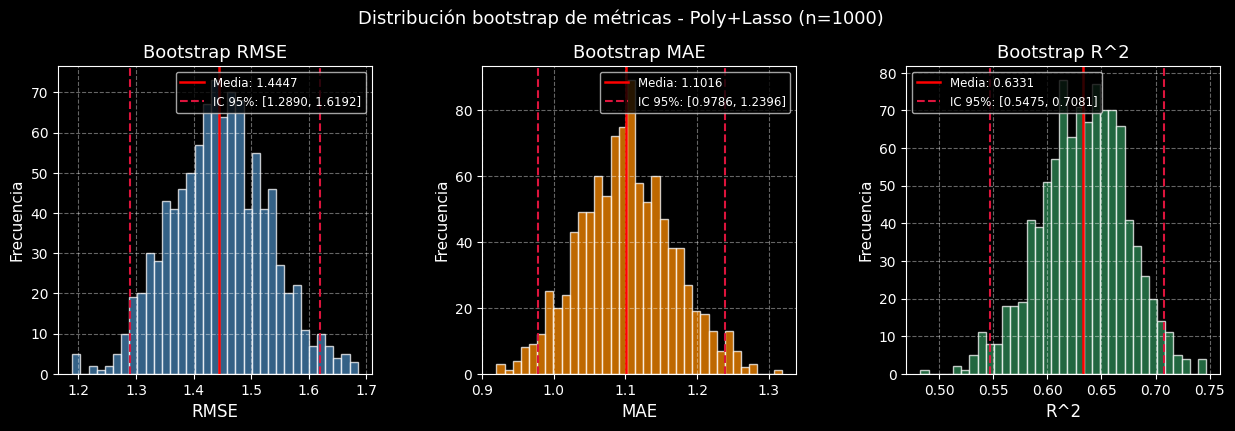

In [430]:
# Gráficas de distribución bootstrap
fig = plt.figure(figsize=(15, 4))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

metrics = [
    (boot_rmse, ic_rmse, 'RMSE', 'steelblue', boot_rmse.mean()),
    (boot_mae, ic_mae, 'MAE', 'darkorange', boot_mae.mean()),
    (boot_r2, ic_r2, 'R^2', 'seagreen', boot_r2.mean()),
]

for ax_idx, (data, (lo, hi), label, color, mu) in enumerate(metrics):
    ax = fig.add_subplot(gs[ax_idx])
    ax.hist(data, bins=35, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(mu, color='red',  linewidth=1.8, linestyle='-',  label=f'Media: {mu:.4f}')
    ax.axvline(lo, color='crimson', linewidth=1.5, linestyle='--', label=f'IC 95%: [{lo:.4f}, {hi:.4f}]')
    ax.axvline(hi, color='crimson', linewidth=1.5, linestyle='--')
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Frecuencia', fontsize=11)
    ax.set_title(f'Bootstrap {label}', fontsize=13)
    ax.legend(fontsize=8.5)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Distribución bootstrap de métricas - Poly+Lasso (n=1000)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Interpretación de los intervalos de confianza

Los 3 intervalos de confianza del RMSE, MAE y R^2 presentan resultados satisfactorios.

- El RMSE tiene un intervalo cuya aplitud es de aproximadamente 0.3, con una desviación estándar baja, lo que indica que el modelo tiene un desempeño consistente en términos de error cuadrático medio.
- El MAE muestra un intervalo aún más estrecho, lo que sugiere que el error absoluto promedio también es estable y no varía mucho entre las muestras bootstrap.
- El R^2 tiene un intervalo que se encuentra completamente por encima de 0.5, en particular oscila entre 0.55 y 0.71, lo que indica que el modelo explica una proporción significativa de la variabilidad en los datos, y la desviación estándar es relativamente baja, lo que refuerza la confianza en la capacidad predictiva.

Por otro lado, los tres intervalos tienen una distribución bastante simétrica y sin colas extremas, lo que sugiere que no hay outliers significativos en las métricas evaluadas. Esto refuerza la idea de que el modelo tiene un desempeño robusto y no está siendo afectado por casos atípicos en el conjunto de prueba.
En conjunto, estos intervalos de confianza sugieren que el modelo polinomial regularizado con Ridge tiene un desempeño robusto y consistente para predecir el puntaje de riesgo cardiovascular en el dataset de Alpes Health.

# Análisis de resultados

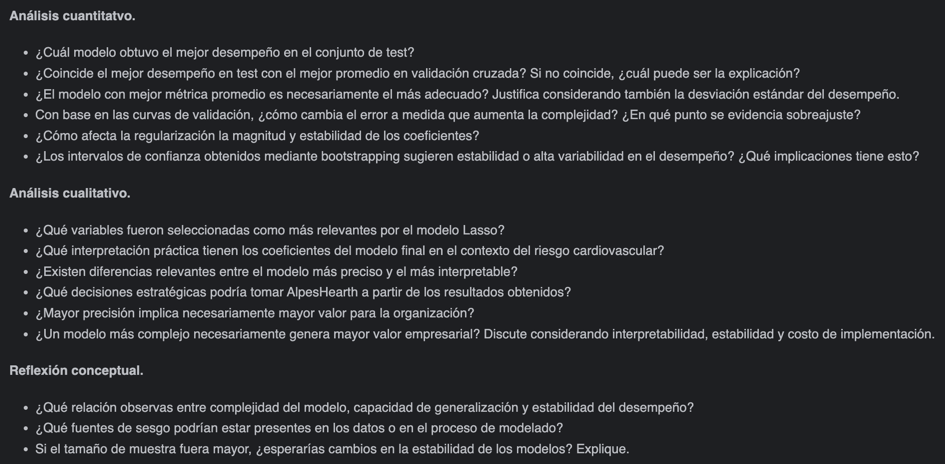
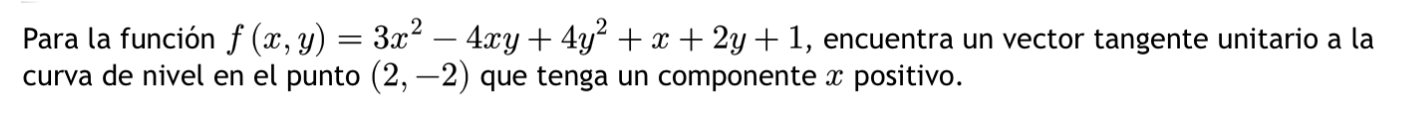

## Análisis cuantitativo

1. El modelo poli-ridge con grado 4, alpha=1 y MinMaxScaler fue el mejor modelo.
2. El modelo poli-ridge no tuvo el mejor RMSE en CV, sino poli-lasso. Esto sugiere que, aunque Lasso es más agresivo en la reducción de coeficientes, en este caso específico la regularización L2 de Ridge logra un mejor equilibrio entre sesgo y varianza, controlando el sobreajuste sin eliminar completamente características potencialmente relevantes.
3. En cuanto a la desviación del desempeño,

## Análisis cualitativo

## Reflexión conceptual

# Uso de IAG

## Declaración de uso

- Herramienta utilizada: Claude Sonnet 4.6
- Tipo de uso: Ayuda conceptual y generación inicial de código para la construcción de las curvas de validación e intervalos de confianza mediante bootstrapping.
- Prompts principales:
    1. "¿Cómo puedo construir curvas de validación para un modelo, variando el grado del polinomio y evaluando el RMSE?"
    2. "¿Cómo puedo implementar un procedimiento de bootstrapping para estimar intervalos de confianza al 95% para las métricas RMSE, MAE y R^2 de un modelo de regresión, utilizando Python?"
- Análisis crítico del resultado:
    - Las respuestas proporcionaron una estructura clara y un código funcional para ambos casos, lo que fue muy útil como punto de partida.
    - Sin embargo, el código generado inicialmente tenía algunos errores menores, como no utilizar `resample` correctamente en el bootstrapping para evaluar contra los datos originales, lo que podría haber llevado a resultados incorrectos.
    - Además, las explicaciones teóricas fueron bastante generales y no se adaptaron completamente al contexto específico del dataset y los modelos utilizados en este proyecto.
- Ajustes realizados:
    - Se hicieron ajustes en el código generado para adaptarlo al contexto específico del dataset y los modelos utilizados, como la integración con pipelines de scikit-learn y la personalización de las gráficas.
    - Se corrigieron algunos errores menores en la implementación del bootstrapping, como asegurar que se evalúe contra los datos originales en cada iteración utilizando `resample` correctamente.